In [2]:
from dotenv import load_dotenv
load_dotenv()



True

In [3]:
from openai import OpenAI
import os
openai_client = OpenAI(
    base_url=os.environ["GROQ_BASE_URL"],
    api_key=os.environ["GROQ_API_KEY"]
)

# Groq models

In [4]:
import requests
import os

api_key = os.environ.get("GROQ_API_KEY")
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

for model in response.json()["data"]:
    print(model)

{'id': 'qwen/qwen3.6-27b', 'object': 'model', 'created': 1778288776, 'owned_by': 'Alibaba Cloud', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 16384, 'hugging_face_id': 'Qwen/Qwen3.6-27B', 'name': 'Qwen/Qwen3.6-27B', 'input_modalities': ['text', 'image'], 'output_modalities': ['text'], 'context_length': 131072, 'max_output_length': 16384, 'pricing': {'prompt': '0.0000006', 'completion': '0.000003', 'image': '0', 'request': '0', 'input_cache_read': '0.0000003'}, 'supported_sampling_parameters': ['temperature', 'top_p', 'stop', 'seed', 'max_tokens'], 'supported_features': ['tools', 'json_mode', 'reasoning']}
{'id': 'groq/compound', 'object': 'model', 'created': 1756949530, 'owned_by': 'Groq', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 8192, 'hugging_face_id': 'groq/compound-beta', 'name': 'Compound', 'input_modalities': ['text'], 'output_modalities': ['text'], 'context_length': 131072, 'max_output_len

# LLM request

In [5]:
def llm(prompt):
    response = openai_client.responses.create(
        model="llama-3.1-8b-instant",
        input=prompt
    )
    return response.output_text

In [6]:
llm("Hey, what's up?")


"Not much. What's on your mind? Want to chat about something in particular or just shoot the breeze?"

# Building the FAQ dataset

In [7]:
import requests

docs_url = "https://datatalks.club/faq/json/courses.json"
response = requests.get(docs_url)
courses_raw = response.json()
courses_raw

[{'course': 'machine-learning-zoomcamp',
  'course_name': 'ML Zoomcamp',
  'path': '/json/machine-learning-zoomcamp.json',
  'questions_count': 471},
 {'course': 'mlops-zoomcamp',
  'course_name': 'MLOps Zoomcamp',
  'path': '/json/mlops-zoomcamp.json',
  'questions_count': 253},
 {'course': 'stock-markets-analytics-zoomcamp',
  'course_name': 'Stock Markets Analytics Zoomcamp',
  'path': '/json/stock-markets-analytics-zoomcamp.json',
  'questions_count': 93},
 {'course': 'ai-dev-tools-zoomcamp',
  'course_name': 'AI Dev Tools Zoomcamp',
  'path': '/json/ai-dev-tools-zoomcamp.json',
  'questions_count': 41},
 {'course': 'data-engineering-zoomcamp',
  'course_name': 'Data Engineering Zoomcamp',
  'path': '/json/data-engineering-zoomcamp.json',
  'questions_count': 404},
 {'course': 'llm-zoomcamp',
  'course_name': 'LLM Zoomcamp',
  'path': '/json/llm-zoomcamp.json',
  'questions_count': 118}]

In [8]:
documents = []
url_prefix = "https://datatalks.club/faq"

for course in courses_raw:
    course_url = f"""{url_prefix}{course["path"]}"""

    course_response = requests.get(course_url)
    course_response.raise_for_status()
    course_data = course_response.json()

    documents.extend(course_data)

len(documents)

1380

In [9]:
documents[0]

{'id': '0e38656cfb',
 'course': 'machine-learning-zoomcamp',
 'section': 'General Course-Related Questions',
 'question': 'How do I submit homework?',
 'answer': "- Do the tasks locally\n- Publish your code (e.g., in your own GitHub repo)\n- Submit your answers via the homework form and include the URL to your code\n- You will see the answers only after the deadline\n- Homeworks are in the cohorts folder, e.g. for 2025 it's [`cohorts/2025`](https://github.com/DataTalksClub/machine-learning-zoomcamp/tree/master/cohorts/2025)\n- The forms for submitting the homework are in the [course management platform](https://courses.datatalks.club/)"}

## Using this data

In the RAG pipeline, this dataset is our knowledge base:

1. We index all the documents (the search step)
2. When a student asks a question, we search the index
3. The search returns the most relevant FAQ entries
4. We give those entries to the LLM as context
5. The LLM generates an answer based on the context

The `question` and `answer` fields contain the text we'll search
through. The `course` field lets us filter by course. For example, if a
student asks about the data engineering course, we skip results from
the ML course. The `section` field helps with ranking - knowing which
part of the course a question belongs to is useful context.

## search engine and indexing data

minsearch is a simple in-memory search engine. It's lightweight, so it runs anywhere Python runs, including Google Colab where you can't start a Docker container. It's a toy implementation, not production ready, but it illustrates how search engines work and it gives good results.

In [10]:
from minsearch import Index

index = Index(
    text_fields=["question", "section", "answer"],
    keyword_fields=["course"]
)

index.fit(documents)

In [ ]:
question = "I just discovered the course. Can I join now?"

"""
We used boost_dict to give the question field more weight (2.0 instead of the default 1.0) and section less weight (0.5). 
Query words appearing in the question field is a stronger signal than them appearing in the section name.
"""
search_results = index.search(
    question,
    boost_dict={"question": 2.0, "section": 0.5},
    filter_dict={"course": "llm-zoomcamp"},
    num_results=5
)

search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '977bf7786c',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
  'answer': "You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date."},
 {'id': '193612db63',
  'course': 'llm-zoomcamp',
  'section': 'Module 3: Orchestration',
  'question': "Why do we need orchestration / Kestra — can't I just run the code in a notebook?",
  'answer': "Notebooks are grea

In [12]:
def search(question, course="llm-zoomcamp"):
    boost_dict = {"question": 2.0, "section": 0.5}
    filter_dict = {"course": course}

    return index.search(
        question,
        boost_dict=boost_dict,
        filter_dict=filter_dict,
        num_results=5
    )

In [14]:
search_results = search(question)
search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '977bf7786c',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
  'answer': "You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date."},
 {'id': '193612db63',
  'course': 'llm-zoomcamp',
  'section': 'Module 3: Orchestration',
  'question': "Why do we need orchestration / Kestra — can't I just run the code in a notebook?",
  'answer': "Notebooks are grea

# Building prompt

In [15]:
USER_PROMPT_TEMPLATE = """
Question:
{question}

Context:
{context}
"""

In [16]:
def build_context(search_results):
    lines = []

    for doc in search_results:
        lines.append(doc["section"])
        lines.append("Q: " + doc["question"])
        lines.append("A: " + doc["answer"])
        lines.append("")

    return "\n".join(lines).strip()

In [17]:
def build_prompt(question, search_results):
    context = build_context(search_results)
    prompt = USER_PROMPT_TEMPLATE.format(
        question=question,
        context=context
    )
    return prompt.strip()

In [26]:
prompt = build_prompt(question, search_results)

print(prompt)

Question:
I just discovered the course. Can I join now?

Context:
General Course-Related Questions
Q: I just discovered the course. Can I still join?
A: Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.

General Course-Related Questions
Q: Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
A: You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

Module 3: Orchestration
Q: Why do we need orchestration / Kestra — can't I just run the code in a notebook?
A: Notebooks are great for learning and experimenting, but real AI workflows need more than a script that runs once: scheduling, retries, monitoring, secret management, and reliably chaining tasks together. That's what an orchest

## Message history

In [33]:
INSTRUCTIONS = """
Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."
"""

message_history = [
    {"role": "developer", "content": INSTRUCTIONS},
    {"role": "user", "content": prompt}
]

response = openai_client.responses.create(
    model="llama-3.1-8b-instant",
    input=message_history
)

response.output_text

'Yes, you can join the course now.'

In [34]:
#update function
def llm(instructions, user_prompt, model="llama-3.1-8b-instant"):
    message_history = [
        {"role": "developer", "content": instructions},
        {"role": "user", "content": user_prompt}
    ]

    response = openai_client.responses.create(
        model=model,
        input=message_history
    )

    return response.output_text

# RAG

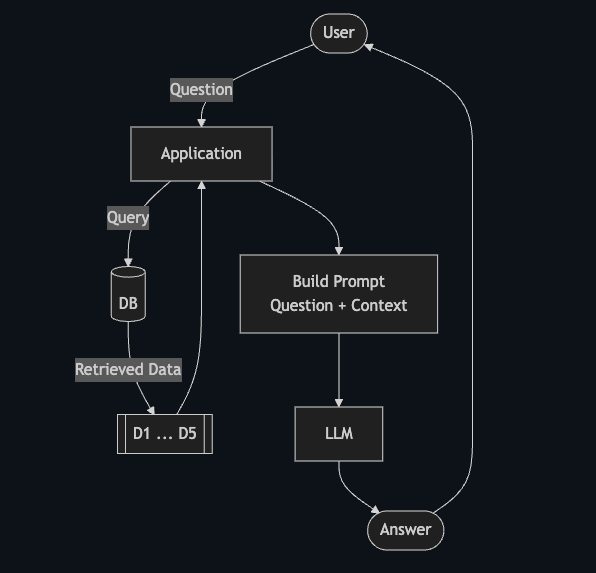

In [36]:
def rag(query, model="llama-3.1-8b-instant"):
    search_results = search(query)
    prompt = build_prompt(query, search_results)
    answer = llm(INSTRUCTIONS, prompt, model=model)
    return answer

In [37]:
answer = rag("I just discovered the course. Can I join now?")
print(answer)

Yes, you can still join now. The course is self-starting, and you can begin learning and submitting homework at any time, as long as the submission form is open. However, to receive a certificate, you need to submit your project while your cohort is still accepting submissions.


In [38]:
rag("How do I get a certificate?")


"Based on the provided information, there are two main ways to get a certificate:\n\n1. **Finish the capstone project and complete the peer reviews:** To get a certificate, you need to finish the capstone project and complete the required peer reviews. You can work through the material and prepare your project in self-paced mode, but project submission and peer review must happen while a live cohort is accepting them.\n2. **Pass the capstone project:** Even if you miss some homework, you can still get a certificate if you pass the capstone project.\n\nAdditionally, you cannot get a certificate in a self-paced mode, but you can work on the material in self-paced mode, and then submit your project and peer reviews when a live cohort is accepting them.\n\nIt's also worth noting that the name you put in the certificate field will not be shown publicly online or shared with third parties."